In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
#import the csv file into a dataframe using pandas to be able to output the results as a readable array for graphing#
df = pd.read_csv('hot_jupiters.csv', engine='python', skiprows=103, header=0)
df. columns = df.columns.str.strip()
print(df.columns.tolist())

['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim', 'st_met', 'st_meterr1', 'st_meterr2', 'st_metlim', 'st_metratio', 'st_logg', 'st

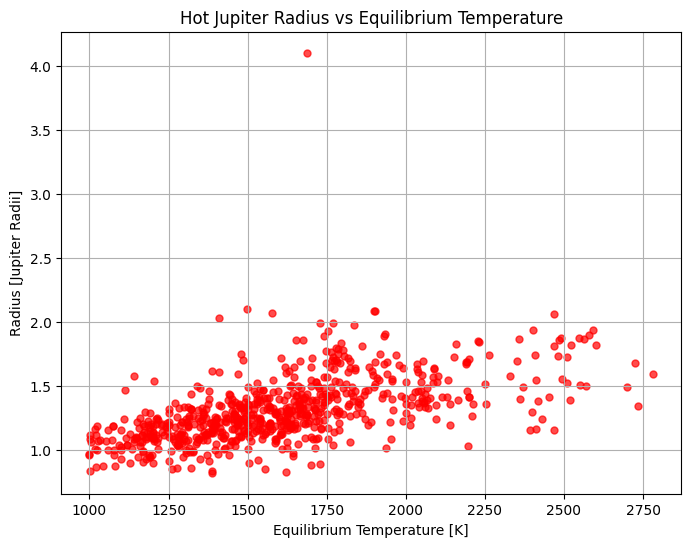

In [3]:
#Scatter plot using the x and y as the equilibrium tempurature and planetary radius#
plt.figure(figsize=(8,6))
plt.scatter(df['pl_eqt'], df['pl_radj'], color='red', alpha=0.7,s=25)
#Label axes#
plt.xlabel('Equilibrium Temperature [K]')
plt.ylabel('Radius [Jupiter Radii]')
plt.title('Hot Jupiter Radius vs Equilibrium Temperature')
plt.grid(True)

In [4]:
#Polyfit function creates a line of best fit for a polynomial of degree n, 1 is used here as data is linearally increasing#
x = df['pl_eqt']
y = df['pl_radj']
m, b = np.polyfit(x, y, 1)

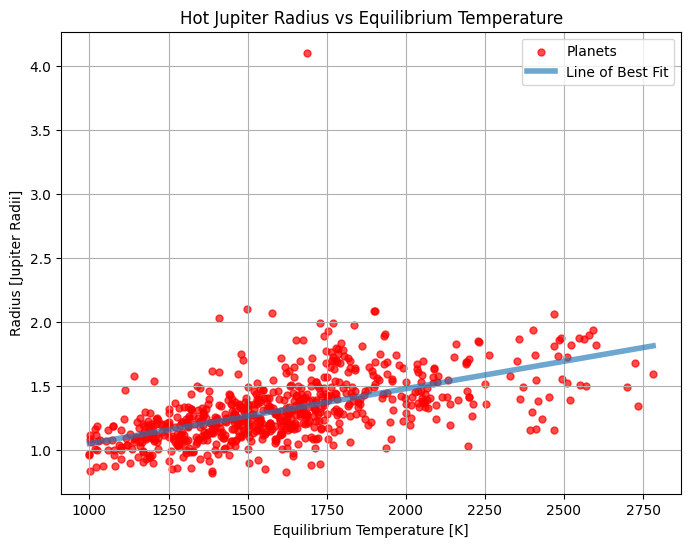

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='red', alpha=0.7,s=25, label='Planets')
plt.xlabel('Equilibrium Temperature [K]')
plt.ylabel('Radius [Jupiter Radii]')
plt.title('Hot Jupiter Radius vs Equilibrium Temperature')
#Plotting line of best fit#
plt.plot(x, m*x+b, label='Line of Best Fit', linewidth=4, alpha=0.65)
plt.grid(True)
plt.legend()

Text(0.5, 1.0, 'Kernel Density Estimation of Radius as a Function of Equilibrium Temp')

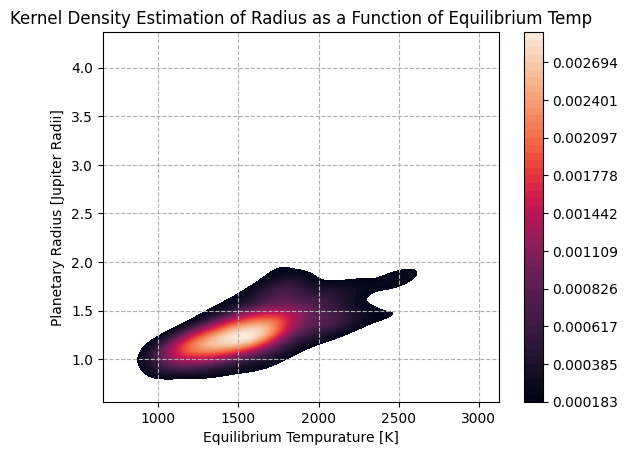

In [16]:
#Kde plot shows density of data in a more readable way than the scatter plot, Highlighting trends better in a visual way.#
kde = sns.kdeplot(
    data=df,
    x='pl_eqt',
    y='pl_radj',
    cmap='rocket', n_levels=50, thresh=0.1, cbar=True, fill=True)
kde.grid(True, linestyle='--')
plt.xlabel('Equilibrium Tempurature [K]')
plt.ylabel('Planetary Radius [Jupiter Radii]')
plt.title('Kernel Density Estimation of Radius as a Function of Equilibrium Temp')

Text(0.5, 1.0, 'Planetary Insolation Flux vs Planetary Radius')

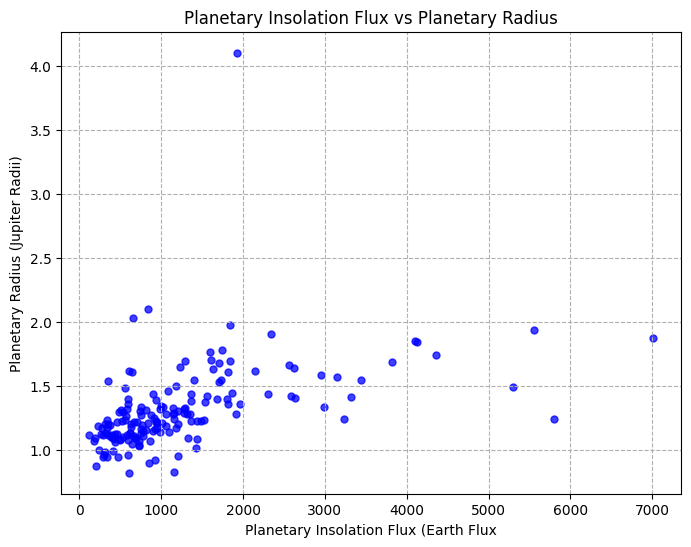

In [7]:
#Further plots show relationship between other variables and Planetary expansion#
plt.figure(figsize=(8,6))
plt.scatter(df['pl_insol'], y, s=25, alpha=0.75, color='blue')
plt.grid(True, linestyle='--')
plt.xlabel('Planetary Insolation Flux (Earth Flux')
plt.ylabel('Planetary Radius (Jupiter Radii)')
plt.title('Planetary Insolation Flux vs Planetary Radius')

Text(0, 0.5, 'Planet Insolation Flux [Earth Flux]')

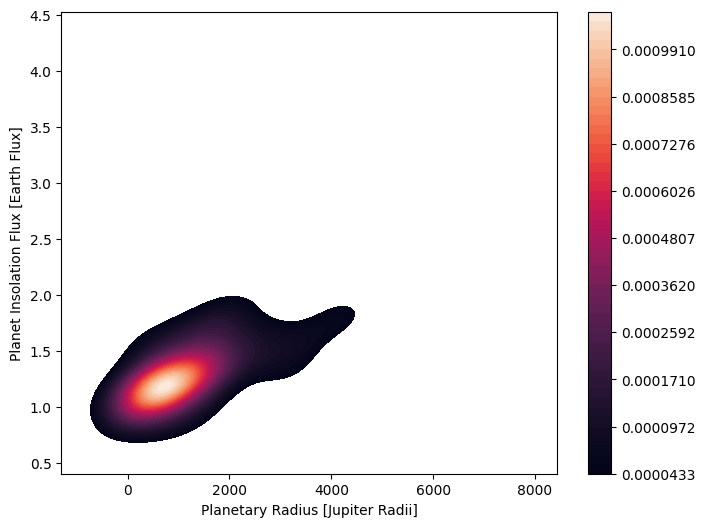

In [17]:
#Kde plot again to distinguish trends#
plt.figure(figsize=(8,6))
kde = sns.kdeplot(
    data=df,
    x='pl_insol', y='pl_radj', 
    fill=True, cbar=True, cmap='rocket', thresh=0.1, n_levels=50)
plt.xlabel('Planetary Radius [Jupiter Radii]')
plt.ylabel('Planet Insolation Flux [Earth Flux]')

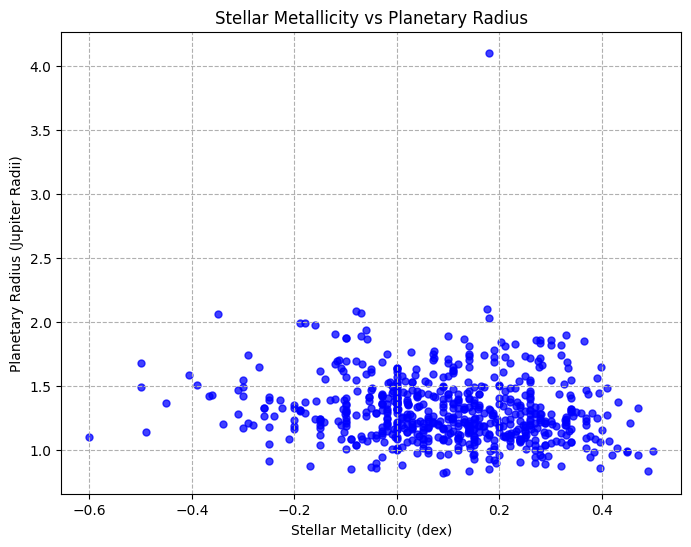

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(df['st_met'], y, s=25, alpha=0.75, color='blue')
plt.ylabel('Planetary Radius (Jupiter Radii)')
plt.xlabel('Stellar Metallicity (dex)')
plt.title('Stellar Metallicity vs Planetary Radius')
plt.grid(True, linestyle='--')

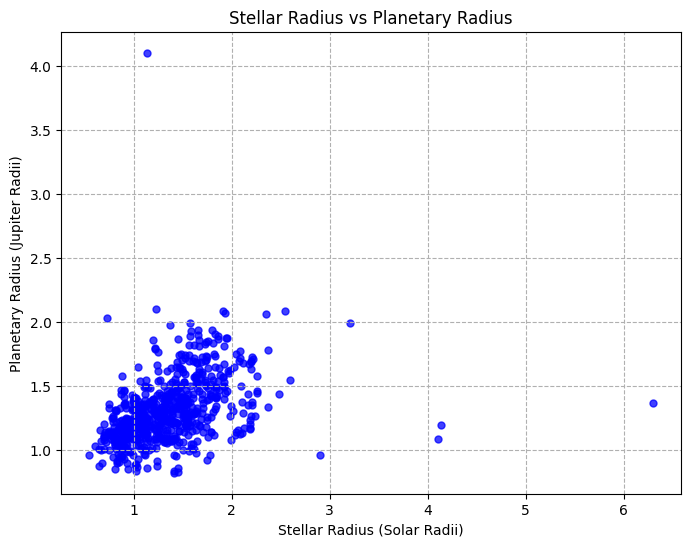

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(df['st_rad'], y, s=25, alpha=0.75, color='blue')
plt.ylabel('Planetary Radius (Jupiter Radii)')
plt.xlabel('Stellar Radius (Solar Radii)')
plt.title('Stellar Radius vs Planetary Radius')
plt.grid(True, linestyle='--')

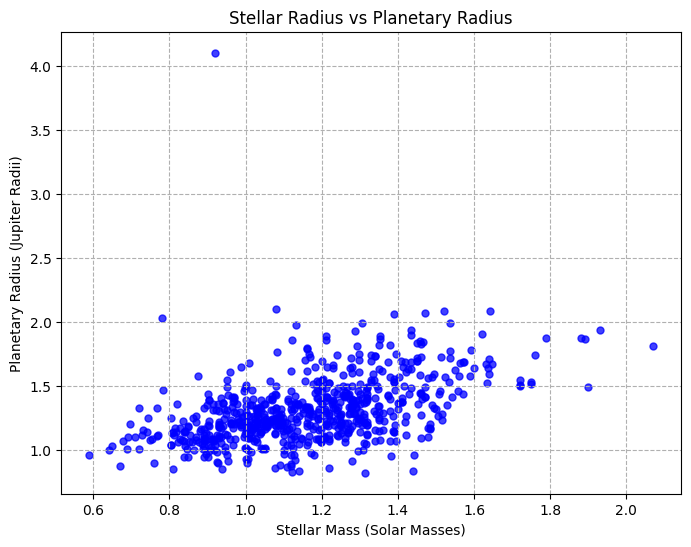

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(df['st_mass'], y, s=25, alpha=0.75, color='blue')
plt.ylabel('Planetary Radius (Jupiter Radii)')
plt.xlabel('Stellar Mass (Solar Masses)')
plt.title('Stellar Radius vs Planetary Radius')
plt.grid(True, linestyle='--')

In [12]:
#Using upper and lower error bars provided in .csv file to create error bars within a scatter plot#
xerrh = np.abs(df['pl_eqterr1'].fillna(0))
xerrl = np.abs(df['pl_eqterr2'].fillna(0))
yerrh = np.abs(df['pl_radjerr1'].fillna(0))
yerrl = np.abs(df['pl_radjerr2'].fillna(0))

x_error = [xerrh, xerrl]
y_error = [yerrh, yerrl]

Text(0, 0.5, 'Planet Radius [Jupiter Radii]')

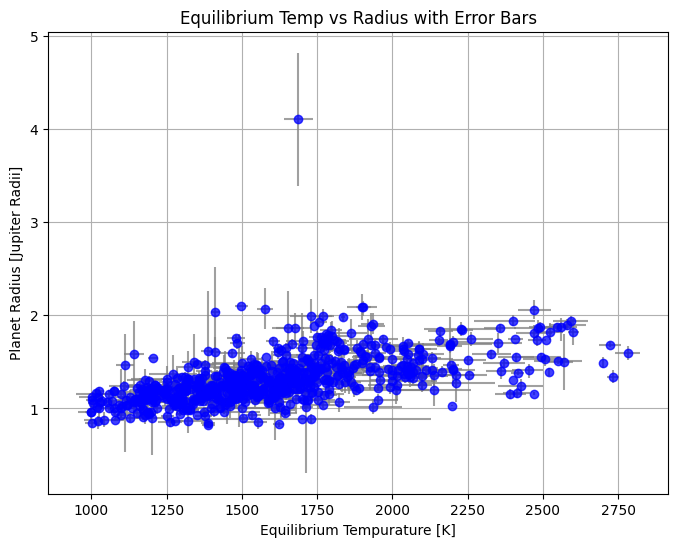

In [18]:
#Plot Earlier figure with Error bars to visualise effect on the data#
plt.figure(figsize=(8,6))
plt.errorbar(x, y, xerr=x_error, yerr=y_error, fmt='o', ecolor='grey', color='blue', alpha=0.75)
plt.grid(True)
plt.title('Equilibrium Temp vs Radius with Error Bars')
plt.xlabel('Equilibrium Tempurature [K]')
plt.ylabel('Planet Radius [Jupiter Radii]') 